# Exercise Sheet 5 — Fast Gradient Methods

This notebook is written in a **simple Python style**.

We solve the exercise about:

1. **Malitsky–Mishchenko step-size control**
2. **Heavy-ball method**
3. **Comparison with normal gradient descent**

The goal is not to write complicated software.  
The goal is to understand the idea and have working code.

## 1. Small idea first

For an optimization problem we want to minimize a function:

$$
\min_x f(x)
$$

Gradient descent uses the formula:

$$
x_{k+1} = x_k - \alpha_k \nabla f(x_k)
$$

Here:

- $x_k$ is the current point
- $\nabla f(x_k)$ is the gradient
- $\alpha_k$ is the step size

If $\alpha_k$ is too small, the method is slow.  
If $\alpha_k$ is too large, the method can jump too far.

## 2. Import Python libraries

We only need NumPy and Matplotlib.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 3. Create the tridiagonal matrix $T_n$

The exercise uses the matrix

$$
T_n =
\begin{bmatrix}
2 & -1 & 0 & \cdots & 0 \\
-1 & 2 & -1 & \cdots & 0 \\
0 & -1 & 2 & \cdots & 0 \\
\vdots & \vdots & \vdots & \ddots & -1 \\
0 & 0 & 0 & -1 & 2
\end{bmatrix}
$$

This matrix is symmetric and positive definite.

In [2]:
def make_T(n):
    """Create the tridiagonal matrix T_n."""
    Q = 2 * np.eye(n)
    
    for i in range(n - 1):
        Q[i, i + 1] = -1
        Q[i + 1, i] = -1
        
    return Q

# Small test
Q_test = make_T(5)
print(Q_test)

[[ 2. -1.  0.  0.  0.]
 [-1.  2. -1.  0.  0.]
 [ 0. -1.  2. -1.  0.]
 [ 0.  0. -1.  2. -1.]
 [ 0.  0.  0. -1.  2.]]


## 4. Functions used in the exercise

We use three functions.

### Function $f_2$

A simple quadratic function:

$$
f_2(x) = \frac{1}{2}x^TQx + p^Tx
$$

Gradient:

$$
\nabla f_2(x) = Qx + p
$$

### Function $f_3$

A non-quadratic convex function:

$$
f_3(x) = \sqrt{1 + x^TQx}
$$

Gradient:

$$
\nabla f_3(x) = \frac{Qx}{\sqrt{1+x^TQx}}
$$

### Function $f_4$

Combination of $f_3$ and a quadratic term:

$$
f_4(x) = f_3(x) + \frac{1}{2}x^TQx
$$

Gradient:

$$
\nabla f_4(x) = \nabla f_3(x) + Qx
$$

Note: if your lecture used $-p^Tx$ instead of $+p^Tx$ for $f_2$, only change one line in `grad_f2`.

In [3]:
def grad_f2(x, Q, p):
    """Gradient of f2."""
    return Q @ x + p


def grad_f3(x, Q):
    """Gradient of f3."""
    Qx = Q @ x
    value_inside_sqrt = 1 + x @ Qx
    return Qx / np.sqrt(value_inside_sqrt)


def grad_f4(x, Q):
    """Gradient of f4."""
    return grad_f3(x, Q) + Q @ x

## 5. Get $L$ and $\mu$ from eigenvalues

For the quadratic matrix $Q$:

- $\mu$ is the smallest eigenvalue
- $L$ is the largest eigenvalue

For $f_3$ we only use $L$, because a positive global $\mu$ is not available.

For $f_4$ we use approximately:

$$
\mu = \lambda_{\min}(Q), \qquad L = 2\lambda_{\max}(Q)
$$

In [4]:
def get_eigen_bounds(Q):
    """Return smallest and largest eigenvalues of Q."""
    eigenvalues = np.linalg.eigvalsh(Q)
    mu = eigenvalues[0]
    L = eigenvalues[-1]
    return mu, L

mu_test, L_test = get_eigen_bounds(Q_test)
print("mu =", mu_test)
print("L  =", L_test)

mu = 0.2679491924311222
L  = 3.7320508075688776


## 6. Normal gradient descent with constant step size

This is the basic method:

$$
x_{k+1} = x_k - \alpha \nabla f(x_k)
$$

We stop when the gradient norm is small.

In [5]:
def gradient_descent(grad, x0, alpha, tol=1e-5, maxit=2000):
    """
    Basic gradient descent.
    
    grad  : function that returns the gradient
    x0    : start vector
    alpha : constant step size
    """
    x = x0.copy()
    residuals = []
    steps = []
    
    for k in range(maxit):
        g = grad(x)
        res = np.linalg.norm(g)
        residuals.append(res)
        
        if res < tol:
            break
        
        x = x - alpha * g
        steps.append(alpha)
        
    return x, np.array(residuals), np.array(steps)

## 7. Malitsky–Mishchenko method

This method tries to estimate a good step size automatically.

It does not need a fixed known $L$ in advance.

The important formula is:

$$
\alpha_k = \min\left\{
\sqrt{1+\theta_{k-1}}\alpha_{k-1},
\frac{\|x_k-x_{k-1}\|}{2\|\nabla f(x_k)-\nabla f(x_{k-1})\|}
\right\}
$$

where

$$
\theta_k = \frac{\alpha_k}{\alpha_{k-1}}
$$

In [6]:
def malitsky_mishchenko(grad, x0, tol=1e-5, maxit=2000):
    """Malitsky-Mishchenko gradient method."""
    alpha_prev = 1e-16
    theta_prev = 1e16
    
    x_prev = x0.copy()
    x = x_prev - alpha_prev * grad(x_prev)
    
    residuals = []
    steps = []
    
    for k in range(1, maxit + 1):
        g = grad(x)
        g_prev = grad(x_prev)
        
        # First possible step size
        alpha_candidate_1 = np.sqrt(1 + theta_prev) * alpha_prev
        
        # Second possible step size
        dx_norm = np.linalg.norm(x - x_prev)
        dg_norm = np.linalg.norm(g - g_prev)
        
        if dg_norm == 0:
            alpha_candidate_2 = np.inf
        else:
            alpha_candidate_2 = dx_norm / (2 * dg_norm)
        
        alpha = min(alpha_candidate_1, alpha_candidate_2)
        
        # Small safety check
        if (not np.isfinite(alpha)) or alpha <= 0:
            alpha = alpha_candidate_1
        
        x_next = x - alpha * g
        res = np.linalg.norm(grad(x_next))
        
        residuals.append(res)
        steps.append(alpha)
        
        if res < tol:
            x = x_next
            break
        
        theta = alpha / alpha_prev
        
        x_prev = x
        x = x_next
        alpha_prev = alpha
        theta_prev = theta
        
    return x, np.array(residuals), np.array(steps)

## 8. Heavy-ball method

The heavy-ball method adds a momentum term:

$$
x_{k+1} = x_k - \alpha \nabla f(x_k) + \beta(x_k-x_{k-1})
$$

It remembers the previous point $x_{k-1}$.

For strongly convex quadratic-like problems we use:

$$
\alpha = \left(\frac{2}{\sqrt{L}+\sqrt{\mu}}\right)^2
$$

and

$$
\beta = \left(\frac{\sqrt{L}-\sqrt{\mu}}{\sqrt{L}+\sqrt{\mu}}\right)^2
$$

In [7]:
def heavy_ball(grad, x0, L, mu, tol=1e-5, maxit=2000):
    """Heavy-ball method."""
    alpha = (2 / (np.sqrt(L) + np.sqrt(mu))) ** 2
    beta = ((np.sqrt(L) - np.sqrt(mu)) / (np.sqrt(L) + np.sqrt(mu))) ** 2
    
    x_prev = x0.copy()
    x = x_prev - alpha * grad(x_prev)
    
    residuals = []
    steps = []
    
    for k in range(1, maxit + 1):
        g = grad(x)
        res = np.linalg.norm(g)
        residuals.append(res)
        steps.append(alpha)
        
        if res < tol:
            break
        
        x_next = x - alpha * g + beta * (x - x_prev)
        
        x_prev = x
        x = x_next
        
    return x, np.array(residuals), np.array(steps), alpha, beta

## 9. Helper function for plotting

We plot:

1. Residual $\|\nabla f(x_k)\|$
2. Step size $\alpha_k$

The residual plot is logarithmic because convergence is easier to see that way.

In [8]:
def plot_results(results, title):
    """
    Plot residuals and step sizes.
    
    results is a dictionary:
    name -> {"res": residuals, "steps": steps}
    """
    plt.figure(figsize=(12, 4))
    
    # Residual plot
    plt.subplot(1, 2, 1)
    for name, data in results.items():
        plt.semilogy(data["res"], label=name)
    plt.xlabel("iteration")
    plt.ylabel("residual norm")
    plt.title("Residual")
    plt.grid(True)
    plt.legend()
    
    # Step size plot
    plt.subplot(1, 2, 2)
    for name, data in results.items():
        if len(data["steps"]) > 0:
            plt.plot(data["steps"], label=name)
    plt.xlabel("iteration")
    plt.ylabel("step size")
    plt.title("Step size")
    plt.grid(True)
    plt.legend()
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

## 10. Run one complete example

This function runs all possible methods for one function and one dimension.

For $f_3$, heavy-ball is skipped because we do not have a global positive $\mu$.

In [9]:
def run_case(function_name, n, tol=1e-5, maxit=2000):
    Q = make_T(n)
    p = np.ones(n)
    x0 = np.ones(n)
    
    mu_Q, L_Q = get_eigen_bounds(Q)
    
    if function_name == "f2":
        grad = lambda x: grad_f2(x, Q, p)
        mu = mu_Q
        L = L_Q
        alpha_gd = 2 / (L + mu)
        can_use_heavy_ball = True
        
    elif function_name == "f3":
        grad = lambda x: grad_f3(x, Q)
        mu = None
        L = L_Q
        alpha_gd = 1 / L
        can_use_heavy_ball = False
        
    elif function_name == "f4":
        grad = lambda x: grad_f4(x, Q)
        mu = mu_Q
        L = 2 * L_Q
        alpha_gd = 2 / (L + mu)
        can_use_heavy_ball = True
        
    else:
        raise ValueError("function_name must be f2, f3, or f4")
    
    results = {}
    
    # Normal gradient descent
    x_gd, res_gd, steps_gd = gradient_descent(
        grad, x0, alpha_gd, tol=tol, maxit=maxit
    )
    results["gradient descent"] = {"x": x_gd, "res": res_gd, "steps": steps_gd}
    
    # Malitsky-Mishchenko
    x_mm, res_mm, steps_mm = malitsky_mishchenko(
        grad, x0, tol=tol, maxit=maxit
    )
    results["Malitsky-Mishchenko"] = {"x": x_mm, "res": res_mm, "steps": steps_mm}
    
    # Heavy-ball if possible
    if can_use_heavy_ball:
        x_hb, res_hb, steps_hb, alpha_hb, beta_hb = heavy_ball(
            grad, x0, L=L, mu=mu, tol=tol, maxit=maxit
        )
        results["heavy-ball"] = {"x": x_hb, "res": res_hb, "steps": steps_hb}
    
    print("Function:", function_name)
    print("Dimension n:", n)
    print("L =", L)
    print("mu =", mu)
    print("constant GD step size =", alpha_gd)
    print()
    
    for method_name, data in results.items():
        print(method_name)
        print("  iterations:", len(data["res"]))
        print("  final residual:", data["res"][-1])
        print()
    
    plot_results(results, title=f"{function_name}, n = {n}")
    
    return results

## 11. Compare methods for $n=5$

We start with a small dimension.  
This is good for learning because it runs fast and is easy to understand.

Function: f2
Dimension n: 5
L = 3.7320508075688776
mu = 0.2679491924311222
constant GD step size = 0.5

gradient descent
  iterations: 89
  final residual: 8.999960072119833e-06

Malitsky-Mishchenko
  iterations: 61
  final residual: 8.69651016705591e-06

heavy-ball
  iterations: 29
  final residual: 6.01573173090077e-06



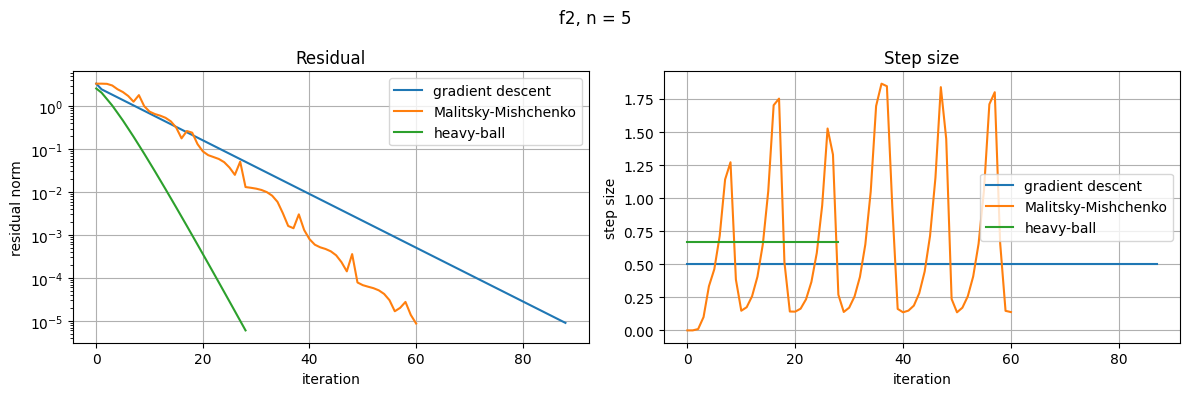

In [10]:
results_f2_n5 = run_case("f2", n=5)

Function: f3
Dimension n: 5
L = 3.7320508075688776
mu = None
constant GD step size = 0.2679491924311227

gradient descent
  iterations: 153
  final residual: 9.611798135349791e-06

Malitsky-Mishchenko
  iterations: 56
  final residual: 9.243127626505922e-06



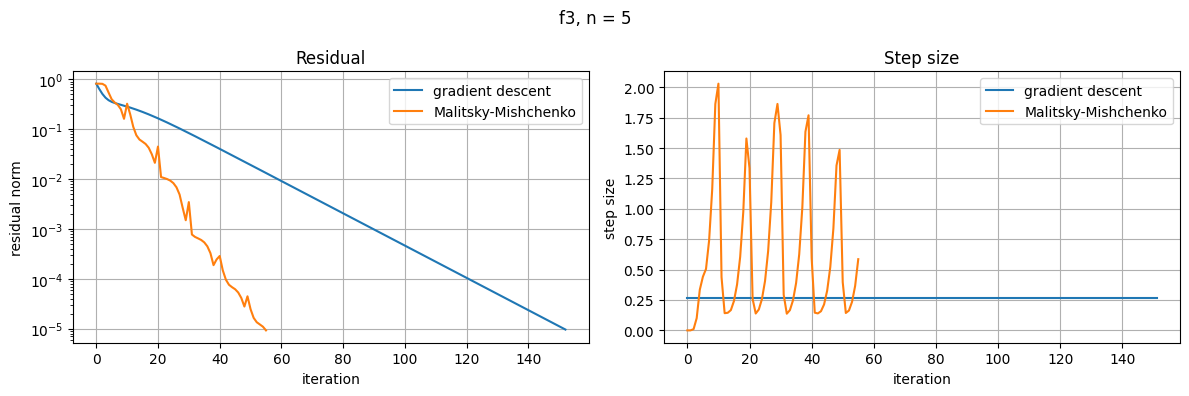

In [11]:
results_f3_n5 = run_case("f3", n=5)

Function: f4
Dimension n: 5
L = 7.464101615137755
mu = 0.2679491924311222
constant GD step size = 0.258663587420068

gradient descent
  iterations: 131
  final residual: 9.64280511749958e-06

Malitsky-Mishchenko
  iterations: 58
  final residual: 9.784619586479133e-06

heavy-ball
  iterations: 40
  final residual: 7.983531335238067e-06



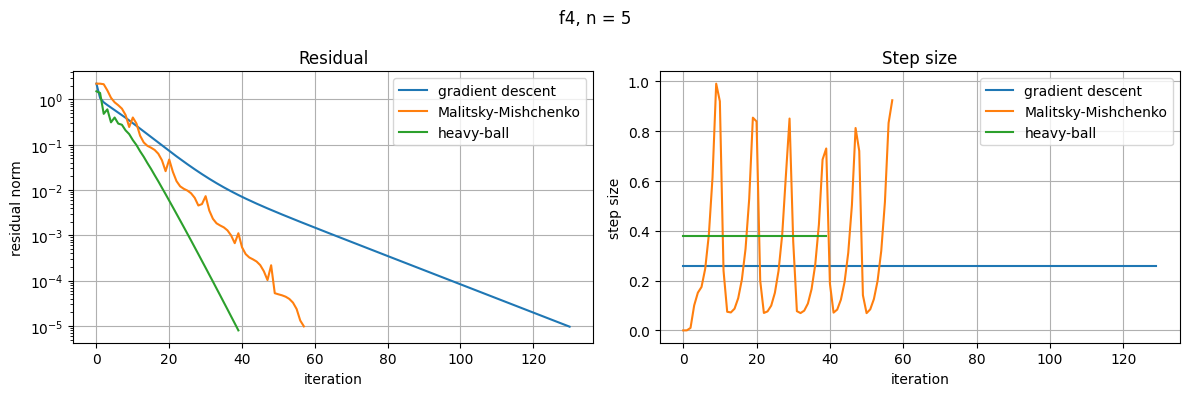

In [12]:
results_f4_n5 = run_case("f4", n=5)

## 12. Compare methods for $n=10$

Now we increase the dimension.

Usually, the problem becomes more difficult when $n$ increases.

Function: f2
Dimension n: 10
L = 3.9189859472289945
mu = 0.08101405277100485
constant GD step size = 0.5000000000000001

gradient descent
  iterations: 308
  final residual: 9.835328745240108e-06

Malitsky-Mishchenko
  iterations: 192
  final residual: 9.73307002293062e-06

heavy-ball
  iterations: 53
  final residual: 9.951444267502078e-06



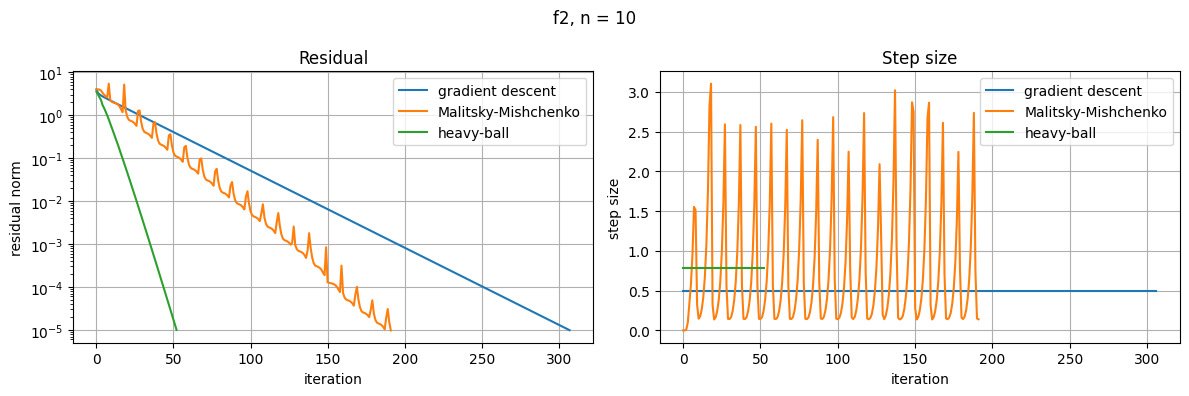

In [13]:
results_f2_n10 = run_case("f2", n=10)

Function: f3
Dimension n: 10
L = 3.9189859472289945
mu = None
constant GD step size = 0.2551680494560263

gradient descent
  iterations: 493
  final residual: 9.987844694111021e-06

Malitsky-Mishchenko
  iterations: 152
  final residual: 9.152799296420864e-06



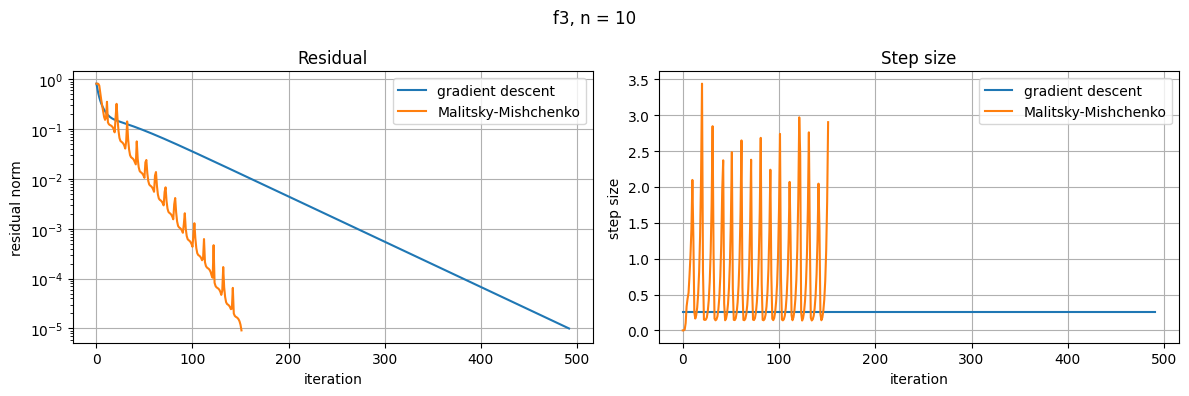

In [14]:
results_f3_n10 = run_case("f3", n=10)

Function: f4
Dimension n: 10
L = 7.837971894457989
mu = 0.08101405277100485
constant GD step size = 0.25255758923272725

gradient descent
  iterations: 262
  final residual: 9.645268546847162e-06

Malitsky-Mishchenko
  iterations: 142
  final residual: 8.47749524482476e-06

heavy-ball
  iterations: 62
  final residual: 8.774169304689422e-06



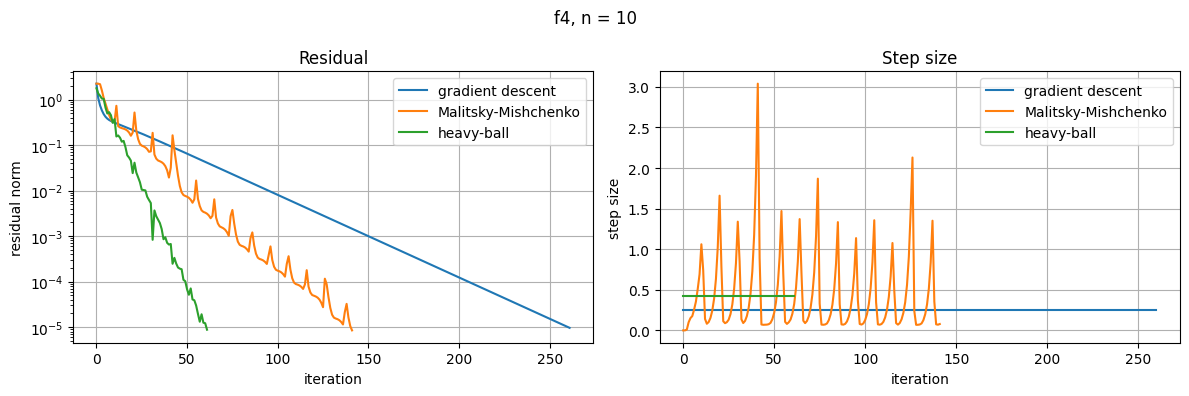

In [15]:
results_f4_n10 = run_case("f4", n=10)

## 13. Optional: try $n=1000$

This is optional because it can take more time.

Uncomment the lines below if you want to test a large dimension.

In [16]:
# results_f2_n1000 = run_case("f2", n=1000, maxit=2000)
# results_f3_n1000 = run_case("f3", n=1000, maxit=2000)
# results_f4_n1000 = run_case("f4", n=1000, maxit=2000)

## 14. What do we observe?

### Normal gradient descent

Normal gradient descent is simple and stable.  
But if the problem becomes badly conditioned, it can become slow.

### Malitsky–Mishchenko method

This method changes the step size automatically.  
This is useful when we do not know the best $L$ value exactly.

For $f_3$, this method is especially useful because a global positive $\mu$ is not available.

### Heavy-ball method

Heavy-ball can be faster for strongly convex problems like $f_2$ and $f_4$.  
But it needs good values of $L$ and $\mu$.

It is not used for $f_3$ here because $f_3$ is not globally $\mu$-convex with a positive $\mu$.

## 15. Memory requirement

Let $n$ be the dimension of the vector $x$.

### Gradient descent

It mainly stores:

- current vector $x_k$
- gradient vector $\nabla f(x_k)$

So the memory requirement is:

$$
O(n)
$$

### Malitsky–Mishchenko method

It stores:

- current vector $x_k$
- previous vector $x_{k-1}$
- current gradient
- previous gradient
- a few scalar values like $\alpha_k$ and $\theta_k$

So the memory requirement is still:

$$
O(n)
$$

### Heavy-ball method

It stores:

- current vector $x_k$
- previous vector $x_{k-1}$
- gradient vector

So the memory requirement is also:

$$
O(n)
$$

Important: all three methods are $O(n)$ in big-O notation.  
But heavy-ball and Malitsky–Mishchenko store more vectors than basic gradient descent.

## 16. Which method would I choose?

### If $L$ and $\mu$ are known

Use **heavy-ball** for strongly convex problems because it can converge faster.

### If $L$ is unknown or difficult to estimate

Use **Malitsky–Mishchenko** because it estimates the step size automatically.

### If I want the simplest method

Use **normal gradient descent**.

It is not always the fastest, but it is easy to understand and easy to debug.

## 17. Small final summary

This exercise shows that the step size is very important.

A good step size can make gradient descent much faster.

- Gradient descent: simple
- Malitsky–Mishchenko: automatic step-size control
- Heavy-ball: faster for strongly convex problems, but needs $L$ and $\mu$